# Avaliação de Modelos: Curva ROC e AUC

Neste material, vamos explorar uma das métricas visuais mais importantes para avaliar o desempenho de classificadores binários: a **Curva ROC** (Receiver Operating Characteristic) e a **AUC** (Área Sob a Curva).

A Curva ROC ilustra a capacidade de diagnóstico de um sistema classificador binário à medida que o seu limiar de discriminação varia. Ela é criada plotando a **Taxa de Verdadeiros Positivos (TPR)**, também conhecida como *Recall* ou *Sensibilidade*, contra a **Taxa de Falsos Positivos (FPR)** em várias configurações de limiar.

O gráfico a seguir gerará uma visualização teórica e idealizada dessa curva, destacando a área sombreada que representa a AUC.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL (PALETA GRAN) ---
COR_AZUL_PRINCIPAL = "#0D134C"
COR_VERMELHO = "#DD303E"
COR_PRETO = "#000000"
COR_BRANCO = "#FFFFFF"
FUNDO_EIXOS = "#F9F9F9"

# Tipografia e Tamanhos de Fonte (Otimizado para PDF)
FONT_LABEL = 20
FONT_TICK = 18
FONT_SUBFIGURE = 24

# Definição do tema base Seaborn
sns.set_theme(style="whitegrid", rc={"axes.facecolor": FUNDO_EIXOS})

# Configuração para suportar glifos matemáticos e padronizar fontes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Fixando a semente para garantir reprodutibilidade
np.random.seed(28)

## Geração dos Dados Sintéticos e Plotagem da Curva ROC

Como estamos elaborando uma explicação teórica sobre o comportamento da curva, utilizaremos o `make_classification` do Scikit-Learn para gerar um conjunto de dados sintético que produza uma curva bem acentuada. Isso facilitará a percepção do aluno sobre o que representa um bom classificador (curva que sobe rapidamente em direção ao canto superior esquerdo).

Lembre-se: **Não utilizaremos títulos no gráfico**. Toda a explicação deve constar no texto da apostila, deixando a área da figura inteiramente dedicada aos dados e suas legendas.

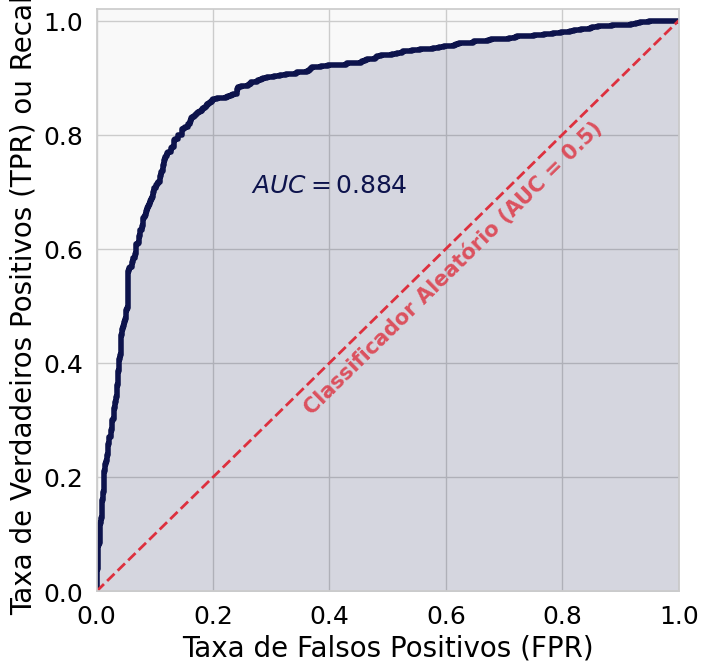

In [ ]:
# 1. Geração de Dados Sintéticos (Teóricos)
# Criando um dataset com boa separabilidade para gerar uma curva dramática/didática
X, y = make_classification(n_samples=2000, n_features=10, n_informative=8, 
                           n_redundant=2, weights=[0.5, 0.5], random_state=28)

# Treinamento de um classificador logístico simples
clf = LogisticRegression()
clf.fit(X, y)
y_prob = clf.predict_proba(X)[:, 1]

# Cálculo das métricas da Curva ROC
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

# 2. Configuração da Figura
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_box_aspect(1) # Força aspecto quadrado para simetria visual no PDF

# 3. Plotagem da Curva ROC e Área Sombreada (AUC)
ax.plot(fpr, tpr, color=COR_AZUL_PRINCIPAL, lw=4, label=f'Curva ROC')
ax.fill_between(fpr, tpr, color=COR_AZUL_PRINCIPAL, alpha=0.15) # Levemente sombreada de azul

# 4. Plotagem do Classificador Aleatório (Diagonal tracejada)
ax.plot([0, 1], [0, 1], color=COR_VERMELHO, lw=2, linestyle='--')

# 5. Formatação dos Eixos
ax.set_xlabel(r'Taxa de Falsos Positivos (FPR)', fontsize=FONT_LABEL, color=COR_PRETO)
ax.set_ylabel(r'Taxa de Verdadeiros Positivos (TPR) ou Recall', fontsize=FONT_LABEL, color=COR_PRETO)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02]) # Um leve respiro superior
ax.tick_params(axis='both', labelsize=FONT_TICK, colors=COR_PRETO)

# 6. Textos e Anotações Conforme Descrição da Imagem
# Texto da linha diagonal ajustado (rotação e eixo y)
ax.text(0.35, 0.31, 'Classificador Aleatório (AUC = 0.5)', 
        rotation=44.5, fontsize=15, color=COR_VERMELHO, fontweight='bold', alpha=0.8)

# Indicação da área sombreada com o valor calculado da AUC em formato matemático
ax.text(0.4, 0.7, rf'$AUC = {roc_auc:.3f}$', 
        fontsize=18, color=COR_AZUL_PRINCIPAL, fontweight='bold', ha='center')

# 7. Ajustes Finais e Exportação
plt.tight_layout(w_pad=2.0)
fig.subplots_adjust(bottom=0.25) # Respiro inferior garantido

# Salvamento na estrutura de diretórios recomendada
caminho_save = os.path.join('..', 'outputs', 'figures', 'aula_02')
os.makedirs(caminho_save, exist_ok=True)

# Salvamento Otimizado para PDF
plt.savefig(os.path.join(caminho_save, 'curva_roc_teorica.png'), 
            dpi=300, bbox_inches='tight', pad_inches=0.4)

plt.show()